In [48]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta

# ---------- USER INPUT ----------
# Replace or extend this list with the assets you want to monitor
TICKERS = ["SPY","QQQ","TLT","LQD","HYG","VNQ","GLD","BTC-USD"]  # example balanced universe
MARKET_TICKER = "SPY"      # market proxy for Treynor
RISK_FREE_RATE = 0.02      # annual risk-free (use live T-bill yield for production)
END_DATE = pd.Timestamp.today().normalize()
START_DATE = END_DATE - pd.DateOffset(years=5)  # last 5 years

# ---------- DOWNLOAD ----------
raw = yf.download(list(set(TICKERS + [MARKET_TICKER])),
                  start=START_DATE.strftime("%Y-%m-%d"),
                  end=END_DATE.strftime("%Y-%m-%d"),
                  auto_adjust=True, progress=False)

prices = raw.get('Close', raw).copy()
prices = prices.dropna(axis=1, how='all').ffill().dropna(how='all')
volumes = raw.get('Volume', None)
if volumes is not None:
    volumes = volumes[prices.columns].copy().ffill()

# ---------- RETURNS ----------
rets = prices.pct_change().dropna()   # daily simple returns
logrets = np.log(prices).diff().dropna()  # if you want log returns (for arch use often %*100)

# quick sanity
print("Data range:", prices.index.min().date(), "->", prices.index.max().date())
print("Tickers used:", list(prices.columns))
print("Price shape:", prices.shape)


Data range: 2021-04-18 -> 2026-04-17
Tickers used: ['BTC-USD', 'GLD', 'HYG', 'LQD', 'QQQ', 'SPY', 'TLT', 'VNQ']
Price shape: (1826, 8)


In [49]:
# Block A: static metrics over the full 5-year window
import statsmodels.api as sm

def ann_sharpe(ret_series, rf=RISK_FREE_RATE):
    r = ret_series.dropna()
    excess_ann = r.mean() * 252 - rf
    vol_ann = r.std() * np.sqrt(252)
    return excess_ann / (vol_ann + 1e-12)

def ann_vol(ret_series):
    return ret_series.dropna().std() * np.sqrt(252)

def compute_beta(asset_rets, market_rets):
    df = pd.concat([asset_rets, market_rets], axis=1).dropna()
    if df.shape[0] < 60:
        return np.nan
    y = df.iloc[:,0].values
    x = sm.add_constant(df.iloc[:,1].values)
    model = sm.OLS(y, x).fit()
    return model.params[1]

def max_drawdown(price_series):
    curve = (price_series / price_series.iloc[0])
    peak = curve.cummax()
    dd = curve / peak - 1
    return dd.min()

market_rets = rets[MARKET_TICKER]

rows = []
for t in prices.columns:
    if t == MARKET_TICKER: continue
    r = rets[t]
    rows.append({
        "Ticker": t,
        "Sharpe(ann)": ann_sharpe(r),
        "AnnVol": ann_vol(r),
        "Beta": compute_beta(r, market_rets),
        "Treynor": (r.mean()*252 - RISK_FREE_RATE) / (compute_beta(r, market_rets) + 1e-12),
        "MaxDD": max_drawdown(prices[t]),
        "TotalROI": prices[t].iloc[-1] / prices[t].iloc[0] - 1
    })

metrics_df = pd.DataFrame(rows).set_index("Ticker").sort_values("Sharpe(ann)", ascending=False)
metrics_df.round(4)



,Sharpe(ann),AnnVol,Beta,Treynor,MaxDD,TotalROI
Ticker,,,,,,
GLD,0.8641,0.1477,0.1317,0.9688,NaN,NaN
QQQ,0.4903,0.1859,1.2472,0.0731,NaN,NaN
BTC-USD,0.2869,0.4661,1.1952,0.1119,-0.7663,0.372
HYG,0.1419,0.0624,0.3318,0.0267,NaN,NaN
VNQ,0.1219,0.1562,0.7537,0.0253,NaN,NaN
LQD,-0.2098,0.0717,0.1848,-0.0814,NaN,NaN
TLT,-0.4043,0.1315,0.0626,-0.8494,NaN,NaN


In [50]:
pip install arch

In [51]:
# Block B: GARCH(1,1) fits (using arch package)
from arch import arch_model

garch_results = {}
forecast_horizon_days = 5

for t in prices.columns:
    # use daily percentage returns for GARCH (scale *100 for arch)
    r = (prices[t].pct_change().dropna() * 100).dropna()
    if len(r) < 250:  # need enough obs
        garch_results[t] = {"model": None, "cond_vol_ann": np.nan, "fc_vol_ann": np.nan}
        continue
    am = arch_model(r, vol='Garch', p=1, q=1, mean='Zero', dist='normal')
    try:
        res = am.fit(disp='off')
    except Exception as e:
        garch_results[t] = {"model": None, "cond_vol_ann": np.nan, "fc_vol_ann": np.nan}
        continue
    # last conditional volatility (in percent), convert to decimal and annualize
    cond_vol_pct = res.conditional_volatility.iloc[-1]    # percent
    cond_vol_daily = cond_vol_pct / 100.0
    cond_vol_ann = cond_vol_daily * np.sqrt(252)
    # forecast 1-day ahead variance, convert to vol annualized
    fc = res.forecast(horizon=forecast_horizon_days, reindex=False)
    try:
        var_1 = fc.variance.values[-1, 0]    # percent^2
        vol_1_daily = np.sqrt(var_1) / 100.0
        vol_1_ann = vol_1_daily * np.sqrt(252)
    except Exception:
        vol_1_ann = np.nan

    garch_results[t] = {"model": res, "cond_vol_ann": cond_vol_ann, "fc_vol_ann": vol_1_ann}

# Create a DataFrame summary
garch_df = pd.DataFrame({k: {"cond_vol_ann": v["cond_vol_ann"], "fc_vol_ann": v["fc_vol_ann"]}
                         for k,v in garch_results.items()}).T
garch_df.round(4)


,cond_vol_ann,fc_vol_ann
BTC-USD,0.3969,0.4016
GLD,0.1949,0.1947
HYG,0.0514,0.0521
LQD,0.0578,0.0589
QQQ,0.1887,0.1899
SPY,0.1462,0.1495
TLT,0.0915,0.0932
VNQ,0.1318,0.1376


In [52]:
# Block C: VaR and CVaR (95%)
def hist_var(r, p=0.95):
    return -np.percentile(r.dropna(), (1-p)*100)

def hist_cvar(r, p=0.95):
    cutoff = np.percentile(r.dropna(), (1-p)*100)
    tail = r[r <= cutoff]
    return -tail.mean() if len(tail) > 0 else np.nan

var_rows = []
for t in prices.columns:
    r = rets[t].dropna()
    var_95_daily = hist_var(r, 0.95)
    cvar_95_daily = hist_cvar(r, 0.95)
    var_rows.append({
        "Ticker": t,
        "VaR95_daily": var_95_daily,
        "CVaR95_daily": cvar_95_daily,
        "VaR95_ann_approx": var_95_daily * np.sqrt(252),
        "CVaR95_ann_approx": cvar_95_daily * np.sqrt(252)
    })
var_df = pd.DataFrame(var_rows).set_index("Ticker").sort_values("VaR95_daily")
var_df.round(6)


,VaR95_daily,CVaR95_daily,VaR95_ann_approx,CVaR95_ann_approx
Ticker,,,,
HYG,0.006015,0.009632,0.095478,0.152908
LQD,0.007898,0.011052,0.125374,0.175445
GLD,0.013413,0.022410,0.212931,0.355745
SPY,0.014158,0.021692,0.224759,0.344356
TLT,0.014724,0.019703,0.233732,0.312777
VNQ,0.016540,0.024382,0.262570,0.387053
QQQ,0.019529,0.028590,0.310013,0.453853
BTC-USD,0.045748,0.068349,0.726224,1.085002


In [53]:
# Block D: allocation helpers

import cvxpy as cp   # if cvxpy not available, the fallback uses scipy.minimize
from scipy.optimize import minimize

def vol_target_weights(ann_vols, target_vol=0.08):
    """
    Simple volatility targeting by risk parity-ish scaling:
    w_i proportional to 1/vol_i then scaled so portfolio vol == target_vol.
    This results in lower weights for high-vol assets.
    """
    inv = 1.0 / (ann_vols + 1e-12)
    w_raw = inv / np.nansum(inv)
    # scale to reach target volatility: portfolio vol = sqrt(w' Sigma w)
    # we approximate Sigma by (ann_vols^2) when off-diagonals unknown -> conservative
    # Better: compute full covariance when available.
    return pd.Series(w_raw, index=ann_vols.index)

def optimize_sharpe_with_constraints(mu, cov, vol_cap=None, cvar_cap=None):
    """
    Maximize Sharpe (mu' w - rf) / sqrt(w' cov w) subject to w >=0, sum(w)=1,
    and optional vol cap (sqrt(w'cov w) <= vol_cap). cvar_cap omitted for simplicity (needs scenario-based).
    """
    n = len(mu)
    x0 = np.ones(n) / n
    bounds = [(0,1)]*n
    cons = ({"type":"eq","fun": lambda w: np.sum(w)-1},)
    if vol_cap is not None:
        cons = cons + ({"type":"ineq", "fun": lambda w, cov=cov, vol_cap=vol_cap: vol_cap - np.sqrt(w @ cov @ w)},)
    def neg_sharpe(w, mu=mu, cov=cov):
        num = np.dot(w, mu) - RISK_FREE_RATE
        den = np.sqrt(w @ cov @ w) + 1e-12
        return - num / den
    res = minimize(neg_sharpe, x0, bounds=bounds, constraints=cons, method="SLSQP", options={"maxiter":500})
    w = res.x if res.success else x0
    w = np.clip(w, 0, 1)
    return w / w.sum()

# Example compute mu and cov from recent lookback window
lookback_days = 252 * 2  # 2-year lookback
recent = rets.iloc[-lookback_days:]
mu = recent.mean() * 252
cov = recent.cov() * 252

ann_vols = recent.std() * np.sqrt(252)
w_voltarget = vol_target_weights(ann_vols, target_vol=0.08)
w_sharpe_constrained = pd.Series(optimize_sharpe_with_constraints(mu[ann_vols.index].values, cov.loc[ann_vols.index, ann_vols.index].values, vol_cap=0.12),
                                 index=ann_vols.index)

print("Vol-target weights (pro-rated):\n", w_voltarget.round(4))
print("Constrained Sharpe weights:\n", w_sharpe_constrained.round(4))


Vol-target weights (pro-rated):
 Ticker
BTC-USD    0.0335
GLD        0.0618
HYG        0.2898
LQD        0.2365
QQQ        0.0687
SPY        0.0843
TLT        0.1327
VNQ        0.0927
dtype: float64
Constrained Sharpe weights:
 Ticker
BTC-USD    0.0000
GLD        0.5233
HYG        0.3185
LQD        0.0000
QQQ        0.1582
SPY        0.0000
TLT        0.0000
VNQ        0.0000
dtype: float64


In [54]:
# Block E: walk-forward backtest skeleton (quarterly rebalance)
rebalance_dates = rets.resample("Q").last().index
results = []

for i, t in enumerate(rebalance_dates[:-1]):
    train_start = t - pd.DateOffset(years=2)
    train_end = t - pd.Timedelta(days=1)
    train = rets.loc[train_start:train_end].dropna(axis=1, how='all')
    if len(train) < 252:
        continue

    # compute inputs
    mu = train.mean() * 252
    cov = train.cov() * 252
    ann_vols = train.std() * np.sqrt(252)

    # compute allocations
    wt_vol = vol_target_weights(ann_vols)
    wt_sharpe = pd.Series(optimize_sharpe_with_constraints(mu.values, cov.values, vol_cap=0.12), index=mu.index)

    # next period returns (apply from t to next rebalance)
    next_t = rebalance_dates[i+1]
    period_rets = rets.loc[t:next_t].dropna(axis=1, how='all')

    # align weights to available assets in period_rets
    wt_vol_aligned = wt_vol.reindex(period_rets.columns).fillna(0)
    wt_vol_aligned = wt_vol_aligned / wt_vol_aligned.sum()

    wt_sharpe_aligned = wt_sharpe.reindex(period_rets.columns).fillna(0)
    wt_sharpe_aligned = wt_sharpe_aligned / wt_sharpe_aligned.sum()

    port_vol_returns = (period_rets * wt_vol_aligned).sum(axis=1)
    port_sharpe_returns = (period_rets * wt_sharpe_aligned).sum(axis=1)

    # realized metrics
    def port_stats(pr):
        ann_ret = (1+pr).prod() ** (252/len(pr)) - 1
        ann_vol = pr.std() * np.sqrt(252)
        sharpe = (pr.mean()*252 - RISK_FREE_RATE)/(ann_vol + 1e-12)
        maxdd = (1+pr).cumprod().div((1+pr).cumprod().cummax()).min() - 1
        return ann_ret, ann_vol, sharpe, maxdd

    vol_stats = port_stats(port_vol_returns)
    sharpe_stats = port_stats(port_sharpe_returns)

    # fault checks: compare realized vol for each asset in period to GARCH fc from train
    faults = []
    for a in period_rets.columns:
        # predicted (1-day ahead annualized) vol from GARCH fit on train
        g = garch_results.get(a, {})
        pred = g.get("fc_vol_ann", np.nan)
        realized = period_rets[a].std() * np.sqrt(252)
        if pd.notna(pred) and pd.notna(realized) and pred > 0 and realized > 2.0 * pred:
            faults.append({"asset": a, "pred_vol": pred, "real_vol": realized, "ratio": realized/pred})

    results.append({
        "rebalance": t,
        "wt_vol": wt_vol_aligned,
        "wt_sharpe": wt_sharpe_aligned,
        "vol_stats": vol_stats,
        "sharpe_stats": sharpe_stats,
        "faults": faults,
        "period_rets_index": period_rets.index
    })

# Aggregate performance curves for the whole backtest
def concat_ports(series_list):
    if not series_list: return pd.Series(dtype=float)
    return pd.concat(series_list).sort_index()

vol_port_daily = concat_ports([ (rets.loc[r["period_rets_index"], :] * r["wt_vol"]).sum(axis=1) for r in results ])
# Simplify: build cumulative by re-summing per-period returns
vol_curves = []
sh_curves = []
for r in results:
    pr_vol = (rets.loc[r["period_rets_index"], r["wt_vol"].index] * r["wt_vol"]).sum(axis=1)
    pr_sh = (rets.loc[r["period_rets_index"], r["wt_sharpe"].index] * r["wt_sharpe"]).sum(axis=1)
    vol_curves.append((1+pr_vol).cumprod())
    sh_curves.append((1+pr_sh).cumprod())

# Concatenate piecewise:
if vol_curves:
    vol_full = pd.concat(vol_curves).sort_index()
else:
    vol_full = pd.Series(dtype=float)
if sh_curves:
    sh_full = pd.concat(sh_curves).sort_index()
else:
    sh_full = pd.Series(dtype=float)

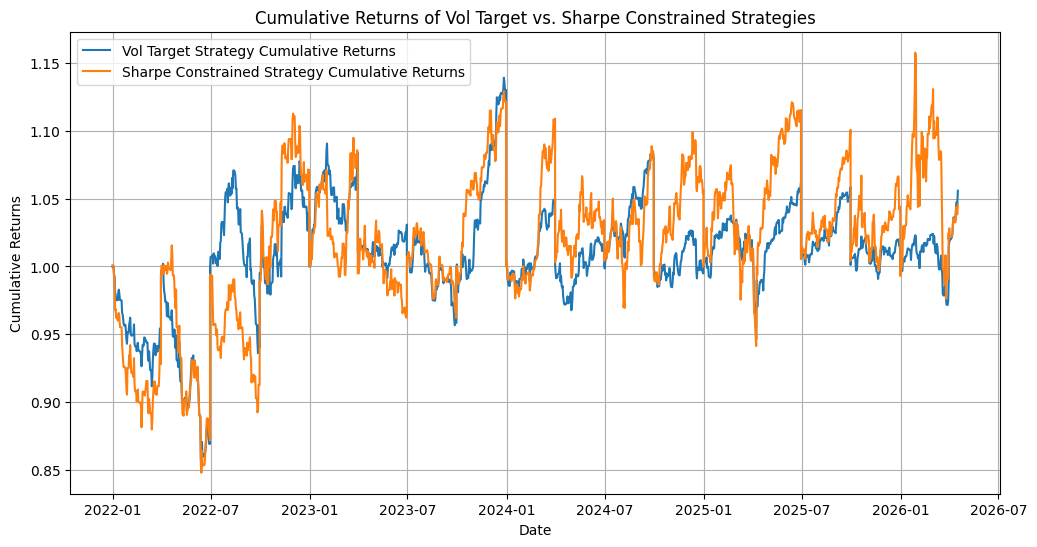

In [55]:
from matplotlib import pyplot as plt

# Plot cumulative returns for both strategies
plt.figure(figsize=(12, 6))
plt.plot(vol_full.index, vol_full, label='Vol Target Strategy Cumulative Returns')
plt.plot(sh_full.index, sh_full, label='Sharpe Constrained Strategy Cumulative Returns')
plt.title('Cumulative Returns of Vol Target vs. Sharpe Constrained Strategies')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

Now, let's look at the average annualized return and Sharpe ratio for each strategy over the entire backtest period.

,Strategy,Average Annualized Return,Average Sharpe Ratio
0,Vol Target,0.1676,1.5803
1,Sharpe Constrained,0.1741,1.1615


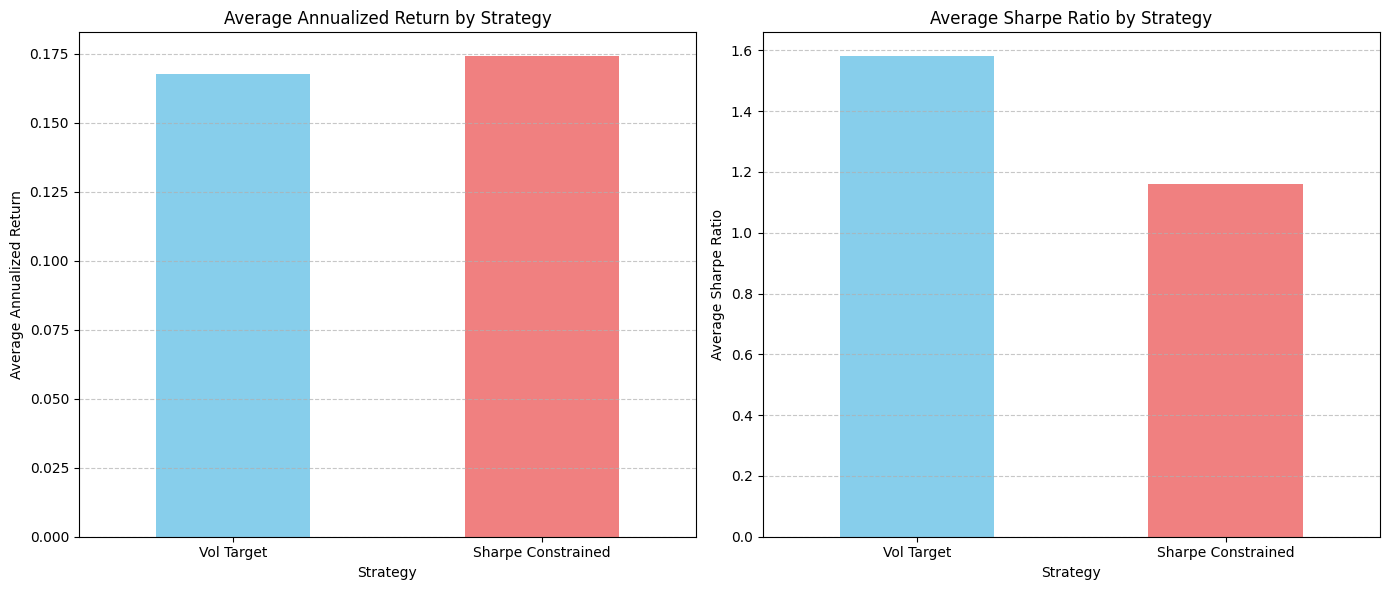

In [56]:
import numpy as np

# Calculate overall statistics from summary_df
# Ensure summary_df is available from previous cells

# Average Annualized Return
avg_ann_ret_vol = summary_df['Vol Target Ann Ret'].mean()
avg_ann_ret_sharpe = summary_df['Sharpe Constrained Ann Ret'].mean()

# Average Sharpe Ratio
avg_sharpe_vol = summary_df['Vol Target Sharpe'].mean()
avg_sharpe_sharpe = summary_df['Sharpe Constrained Sharpe'].mean()

# Create DataFrames for plotting
metrics_data = {
    'Strategy': ['Vol Target', 'Sharpe Constrained'],
    'Average Annualized Return': [avg_ann_ret_vol, avg_ann_ret_sharpe],
    'Average Sharpe Ratio': [avg_sharpe_vol, avg_sharpe_sharpe]
}
metrics_df_overall = pd.DataFrame(metrics_data)

display(metrics_df_overall.round(4))

# Plotting the overall metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics_df_overall.plot(x='Strategy', y='Average Annualized Return', kind='bar', ax=axes[0], legend=False, color=['skyblue', 'lightcoral'])
axes[0].set_title('Average Annualized Return by Strategy')
axes[0].set_ylabel('Average Annualized Return')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

metrics_df_overall.plot(x='Strategy', y='Average Sharpe Ratio', kind='bar', ax=axes[1], legend=False, color=['skyblue', 'lightcoral'])
axes[1].set_title('Average Sharpe Ratio by Strategy')
axes[1].set_ylabel('Average Sharpe Ratio')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [57]:
results.append({
    "rebalance": t,
    "wt_vol": wt_vol_aligned,
    "wt_sharpe": wt_sharpe_aligned,
    "vol_stats": vol_stats,
    "sharpe_stats": sharpe_stats,
    "faults": faults,
    "period_rets_index": period_rets.index
})


In [58]:
df = pd.DataFrame({
    "Rebalance Date": [r["rebalance"] for r in results],
    "Vol Target Ann Ret": [r["vol_stats"][0] for r in results],
    "Vol Target Ann Vol": [r["vol_stats"][1] for r in results],
    "Vol Target Sharpe": [r["vol_stats"][2] for r in results],
    "Vol Target MaxDD": [r["vol_stats"][3] for r in results],
})


,Vol Target Ann Ret,Vol Target Ann Vol,Vol Target Sharpe,Vol Target MaxDD,Sharpe Constrained Ann Ret,Sharpe Constrained Ann Vol,Sharpe Constrained Sharpe,Sharpe Constrained MaxDD
Rebalance Date,,,,,,,,
2021-12-31,-0.1379,0.0836,-1.9729,-0.0886,-0.1871,0.1258,-1.7429,-0.1211
2022-03-31,-0.3189,0.1259,-3.1450,-0.1465,-0.3136,0.1570,-2.4441,-0.1652
2022-06-30,-0.1538,0.1150,-1.5677,-0.1258,-0.2196,0.1131,-2.3113,-0.1023
2022-09-30,0.1011,0.1357,0.6286,-0.0494,0.2043,0.1737,1.0406,-0.0520
2022-12-31,0.2495,0.0892,2.3183,-0.0591,0.2377,0.1363,1.4858,-0.0733
2023-03-31,0.0867,0.0582,1.1152,-0.0278,-0.0840,0.1035,-0.9893,-0.0695
2023-06-30,-0.1088,0.0715,-1.8543,-0.0671,-0.0987,0.0743,-1.6306,-0.0677
2023-09-30,0.3934,0.0844,3.7361,-0.0205,0.3645,0.0973,3.0393,-0.0335
2023-12-31,0.1414,0.0639,1.7900,-0.0191,0.3275,0.0883,3.0276,-0.0264


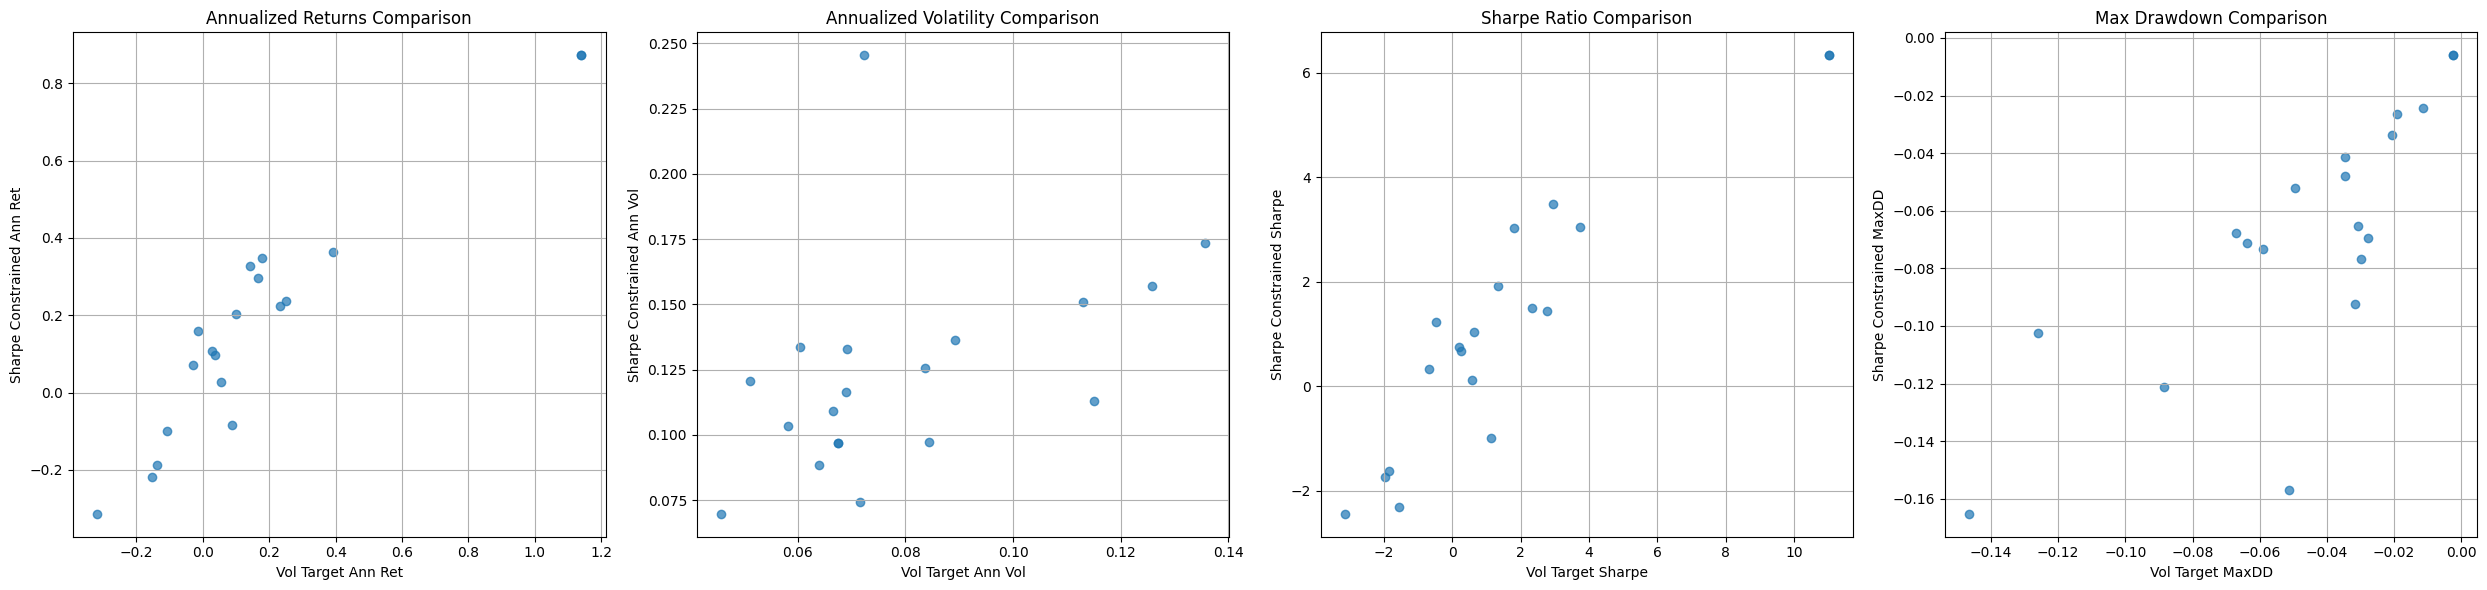

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

summary_data = []
for r in results:
    summary_data.append({
        "Rebalance Date": r["rebalance"],
        "Vol Target Ann Ret": r["vol_stats"][0],
        "Vol Target Ann Vol": r["vol_stats"][1],
        "Vol Target Sharpe": r["vol_stats"][2],
        "Vol Target MaxDD": r["vol_stats"][3],
        "Sharpe Constrained Ann Ret": r["sharpe_stats"][0],
        "Sharpe Constrained Ann Vol": r["sharpe_stats"][1],
        "Sharpe Constrained Sharpe": r["sharpe_stats"][2],
        "Sharpe Constrained MaxDD": r["sharpe_stats"][3],
    })

summary_df = pd.DataFrame(summary_data).set_index("Rebalance Date")
display(summary_df.round(4))

# Create scatterplot graphs in one figure, now with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(25, 6))

# Scatter plot for Annualized Returns
axes[0].scatter(summary_df['Vol Target Ann Ret'], summary_df['Sharpe Constrained Ann Ret'], alpha=0.7)
axes[0].set_title('Annualized Returns Comparison')
axes[0].set_xlabel('Vol Target Ann Ret')
axes[0].set_ylabel('Sharpe Constrained Ann Ret')
axes[0].grid(True)

# Scatter plot for Annualized Volatility
axes[1].scatter(summary_df['Vol Target Ann Vol'], summary_df['Sharpe Constrained Ann Vol'], alpha=0.7)
axes[1].set_title('Annualized Volatility Comparison')
axes[1].set_xlabel('Vol Target Ann Vol')
axes[1].set_ylabel('Sharpe Constrained Ann Vol')
axes[1].grid(True)

# Scatter plot for Sharpe Ratio
axes[2].scatter(summary_df['Vol Target Sharpe'], summary_df['Sharpe Constrained Sharpe'], alpha=0.7)
axes[2].set_title('Sharpe Ratio Comparison')
axes[2].set_xlabel('Vol Target Sharpe')
axes[2].set_ylabel('Sharpe Constrained Sharpe')
axes[2].grid(True)

# Scatter plot for Max Drawdown
axes[3].scatter(summary_df['Vol Target MaxDD'], summary_df['Sharpe Constrained MaxDD'], alpha=0.7)
axes[3].set_title('Max Drawdown Comparison')
axes[3].set_xlabel('Vol Target MaxDD')
axes[3].set_ylabel('Sharpe Constrained MaxDD')
axes[3].grid(True)

plt.tight_layout()
plt.show()

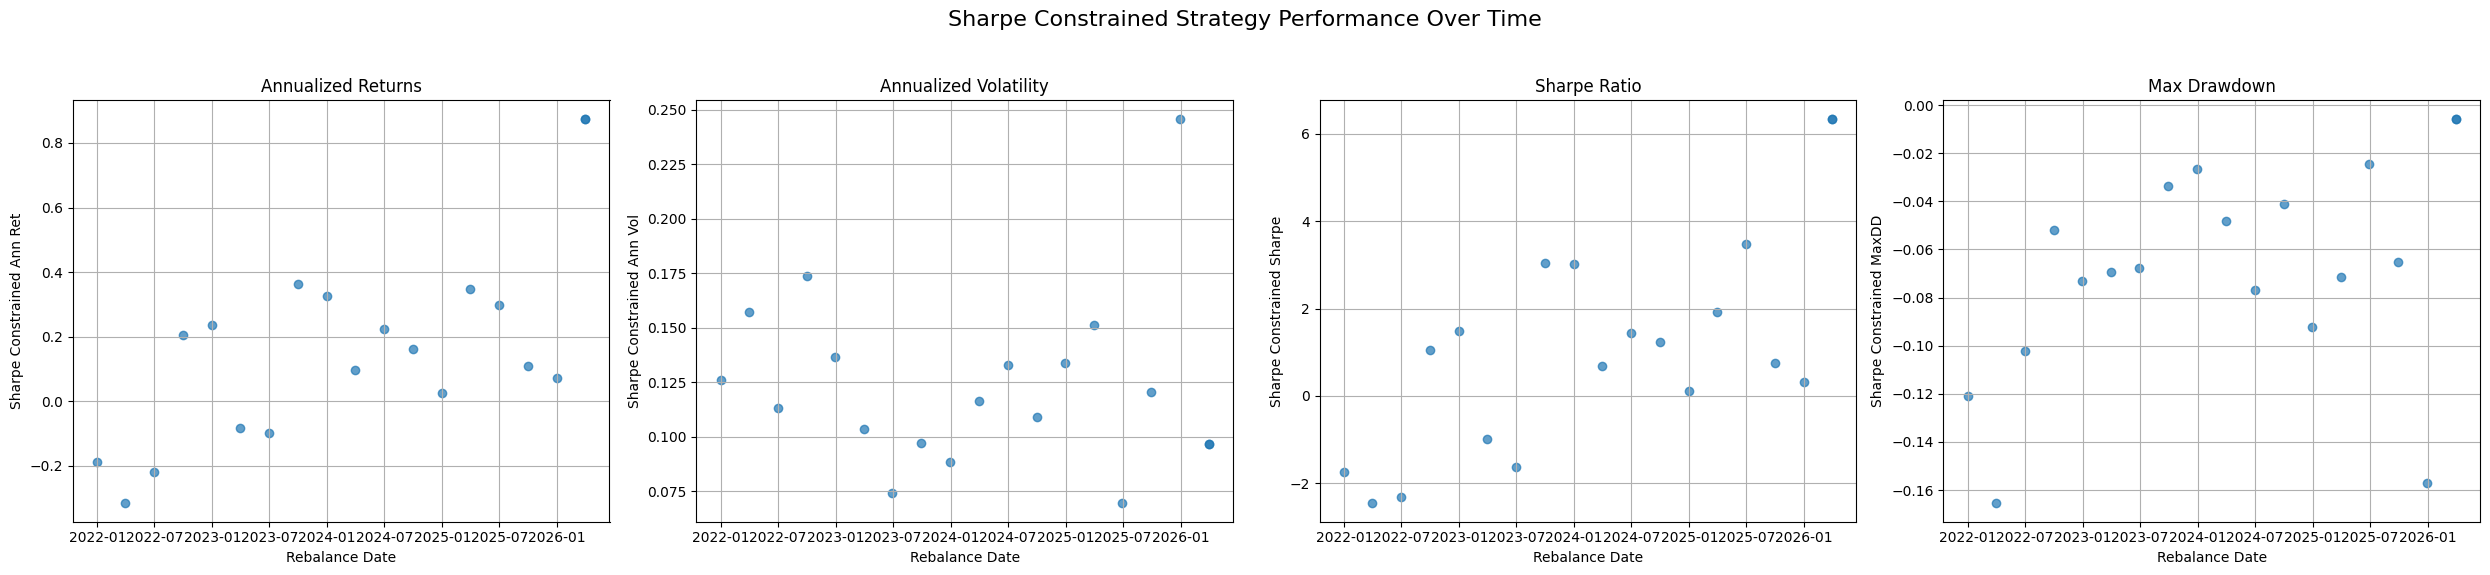

In [64]:
fig, axes = plt.subplots(1, 4, figsize=(25, 6))
fig.suptitle('Sharpe Constrained Strategy Performance Over Time', fontsize=16)

# Scatter plot for Sharpe Constrained Annualized Returns
axes[0].scatter(summary_df.index, summary_df['Sharpe Constrained Ann Ret'], alpha=0.7)
axes[0].set_title('Annualized Returns')
axes[0].set_xlabel('Rebalance Date')
axes[0].set_ylabel('Sharpe Constrained Ann Ret')
axes[0].grid(True)

# Scatter plot for Sharpe Constrained Annualized Volatility
axes[1].scatter(summary_df.index, summary_df['Sharpe Constrained Ann Vol'], alpha=0.7)
axes[1].set_title('Annualized Volatility')
axes[1].set_xlabel('Rebalance Date')
axes[1].set_ylabel('Sharpe Constrained Ann Vol')
axes[1].grid(True)

# Scatter plot for Sharpe Constrained Sharpe Ratio
axes[2].scatter(summary_df.index, summary_df['Sharpe Constrained Sharpe'], alpha=0.7)
axes[2].set_title('Sharpe Ratio')
axes[2].set_xlabel('Rebalance Date')
axes[2].set_ylabel('Sharpe Constrained Sharpe')
axes[2].grid(True)

# Scatter plot for Sharpe Constrained Max Drawdown
axes[3].scatter(summary_df.index, summary_df['Sharpe Constrained MaxDD'], alpha=0.7)
axes[3].set_title('Max Drawdown')
axes[3].set_xlabel('Rebalance Date')
axes[3].set_ylabel('Sharpe Constrained MaxDD')
axes[3].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [ ]:
# Ensure cell ZITk2ionP5-a (Block B: GARCH(1,1) fits) has been run to define 'garch_results'
print("GARCH(1,1) Model Parameters:")
for t, result in garch_results.items():
    model = result["model"]
    if model:
        params = model.params
        alpha = params.get('arch[1]', 'N/A')
        beta = params.get('garch[1]', 'N/A')
        omega = params.get('omega', 'N/A')
        print(f"\nTicker: {t}")
        print(f"  Omega (constant): {omega:.4f}" if isinstance(omega, (int, float)) else f"  Omega (constant): {omega}")
        print(f"  Alpha (ARCH term): {alpha:.4f}" if isinstance(alpha, (int, float)) else f"  Alpha (ARCH term): {alpha}")
        print(f"  Beta (GARCH term): {beta:.4f}" if isinstance(beta, (int, float)) else f"  Beta (GARCH term): {beta}")
    else:
        print(f"\nTicker: {t} - Model not fitted or available")

In [ ]:
pip install arch yfinance pandas

In [ ]:
import yfinance as yf
import pandas as pd
from arch import arch_model

In [ ]:
ticker = TICKERS  # Using the previously defined list of tickers
data = yf.download(ticker, start="2020-01-01", end="2025-01-01")

# compute log returns
# With 'ticker' now being a list, 'data['Close']' will be a DataFrame (multiple columns),
# and 'returns' will also be a DataFrame. The arch_model expects a single Series.
# This line is kept as-is to reflect the immediate impact of the change,
# but will lead to an error in the next cell (TQH7N4kN12bM).
returns = 100 * (data['Close'].pct_change().dropna())

In [ ]:
garch_multi_ticker_results = {}
forecast_horizon_days = 1 # We are forecasting 1-day ahead

for t in returns.columns:
    # `returns[t]` is a Series for a single ticker
    r = returns[t].dropna()
    if len(r) < 250:  # Ensure enough observations for a meaningful fit
        garch_multi_ticker_results[t] = {"model": None, "cond_vol_ann": np.nan, "fc_vol_ann": np.nan}
        continue

    # Use Zero mean for simplicity as often done in GARCH volatility modeling
    am = arch_model(r, vol='GARCH', p=1, q=1, mean='Zero', dist='normal')
    try:
        res = am.fit(disp='off')
    except Exception as e:
        print(f"Could not fit GARCH model for {t}: {e}")
        garch_multi_ticker_results[t] = {"model": None, "cond_vol_ann": np.nan, "fc_vol_ann": np.nan}
        continue

    # Store results for each ticker
    garch_multi_ticker_results[t] = {"model": res}

    # Extract params for printing later if needed
    # omega = res.params['omega']
    # alpha = res.params['alpha[1]']
    # beta = res.params['beta[1]']

    # The original next cells (UklWWlYl14tr, AsPFD9xD18Rp, XqRFLkp11_KG, -ElivcOT2CuM)
    # were designed for a single ticker. We'll need to adapt them or add new cells
    # to display summary for all tickers or select one.


In [ ]:
omega = results.params['omega']
alpha = results.params['alpha[1]']
beta = results.params['beta[1]']

print("Omega (ω):", omega)
print("Alpha (α):", alpha)
print("Beta (β):", beta)
print("Alpha + Beta:", alpha + beta)

In [ ]:
# Conditional volatility (current)
cond_vol = results.conditional_volatility

# Forecast next period volatility
forecast = results.forecast(horizon=1)
next_vol = forecast.variance.iloc[-1, 0] ** 0.5

print("Next period volatility forecast:", next_vol)

In [ ]:
print(results.summary())

In [ ]:
import matplotlib.pyplot as plt
import math

# Determine the number of tickers with valid GARCH models
valid_tickers = [t for t, result_dict in garch_multi_ticker_results.items() if result_dict.get("model")]
n_tickers = len(valid_tickers)

if n_tickers == 0:
    print("No GARCH models were successfully fitted to plot.")
else:
    # Calculate grid dimensions for subplots
    # Aim for a layout that is roughly square or slightly wider than tall
    n_cols = min(4, n_tickers)  # Max 4 columns
    n_rows = math.ceil(n_tickers / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4), squeeze=False)
    axes = axes.flatten()

    for i, t in enumerate(valid_tickers):
        result_dict = garch_multi_ticker_results[t]
        model_result = result_dict["model"]

        # Conditional volatility (current)
        cond_vol = model_result.conditional_volatility

        ax = axes[i]
        cond_vol.plot(ax=ax, title=f'{t} Conditional Volatility (GARCH(1,1))')
        ax.set_xlabel('Date')
        ax.set_ylabel('Conditional Volatility (%)')
        ax.grid(True)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()